In [197]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import backtrader as bt

from sklearn.ensemble import RandomForestClassifier

In [198]:
# Download S&P 500 data
data = yf.download("^GSPC", start="2020-01-01", end="2025-01-01", auto_adjust=False, progress=False)


data = (
    data.rename(columns=str.lower)
      .drop(columns=["adj close", 'volume'])
      .dropna()
)

data.columns = data.columns.droplevel(1)
data.columns.name = None





# Columns you'll get: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [216]:
data

,close,high,low,open
Date,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088
...,...,...,...,...
2024-12-24,6040.040039,6040.100098,5981.439941,5984.629883
2024-12-26,6037.589844,6049.750000,6007.370117,6024.970215
2024-12-27,5970.839844,6006.169922,5932.950195,6006.169922


### Visualise data

In [191]:
# Quick line chart of closing prices
data['close'].plot(title="S&P 500 Price")
plt.show()

# Check basic stats
print(data.describe())

<IPython.core.display.Javascript object>

             close         high          low         open
count  1258.000000  1258.000000  1258.000000  1258.000000
mean   4259.606933  4283.980701  4232.242692  4258.915009
std     767.448592   765.438426   769.613238   767.478053
min    2237.399902  2300.729980  2191.860107  2290.709961
25%    3819.052551  3846.012512  3791.585022  3817.265015
50%    4204.880127  4233.785156  4186.004883  4206.094971
75%    4603.890137  4631.122681  4579.504883  4602.849854
max    6090.270020  6099.970215  6079.979980  6089.029785


### Add new collumns

`return` → daily % change

`ma_5, ma_20` → short-term and longer-term trend

`momentum` → how much price changed over 5 days

`dropna()` → cleans up the first few rows that don’t have enough history

In [192]:
df = data.copy()

# Calculate percentage change from previous row
df["return"] = df["close"].pct_change()

# Calculate moving average, shows trend direction
df["ma_5"] = backtester_df["close"].rolling(5).mean() # 5 days
df["ma_20"] = df["close"].rolling(20).mean() # 20 days

# Captures how fast price is moving
df["momentum"] = df["close"] - df["close"].shift(5)

# Removes NaN
df.dropna(inplace=True)

In [193]:
df

,close,high,low,open,return,ma_5,ma_20,momentum
Date,,,,,,,,
2023-10-13,4327.779785,4377.100098,4311.970215,4360.490234,-0.005019,4349.648047,4325.974512,19.279785
2023-10-16,4373.629883,4383.330078,4342.370117,4342.370117,0.010594,4357.241992,4321.979517,37.969727
2023-10-17,4373.200195,4393.569824,4337.540039,4345.229980,-0.000098,4360.233984,4318.442017,14.959961
2023-10-18,4314.600098,4364.200195,4303.839844,4357.350098,-0.013400,4347.763965,4314.062012,-62.350098
2023-10-19,4278.000000,4339.540039,4269.689941,4321.359863,-0.008483,4333.441992,4311.462012,-71.609863
...,...,...,...,...,...,...,...,...
2024-12-24,6040.040039,6040.100098,5981.439941,5984.629883,0.011043,5936.840039,6024.241504,-10.569824
2024-12-26,6037.589844,6049.750000,6007.370117,6024.970215,-0.000406,5969.925977,6025.039502,165.429688
2024-12-27,5970.839844,6006.169922,5932.950195,6006.169922,-0.011056,5990.677930,6023.644482,103.759766


### Plot new collumns

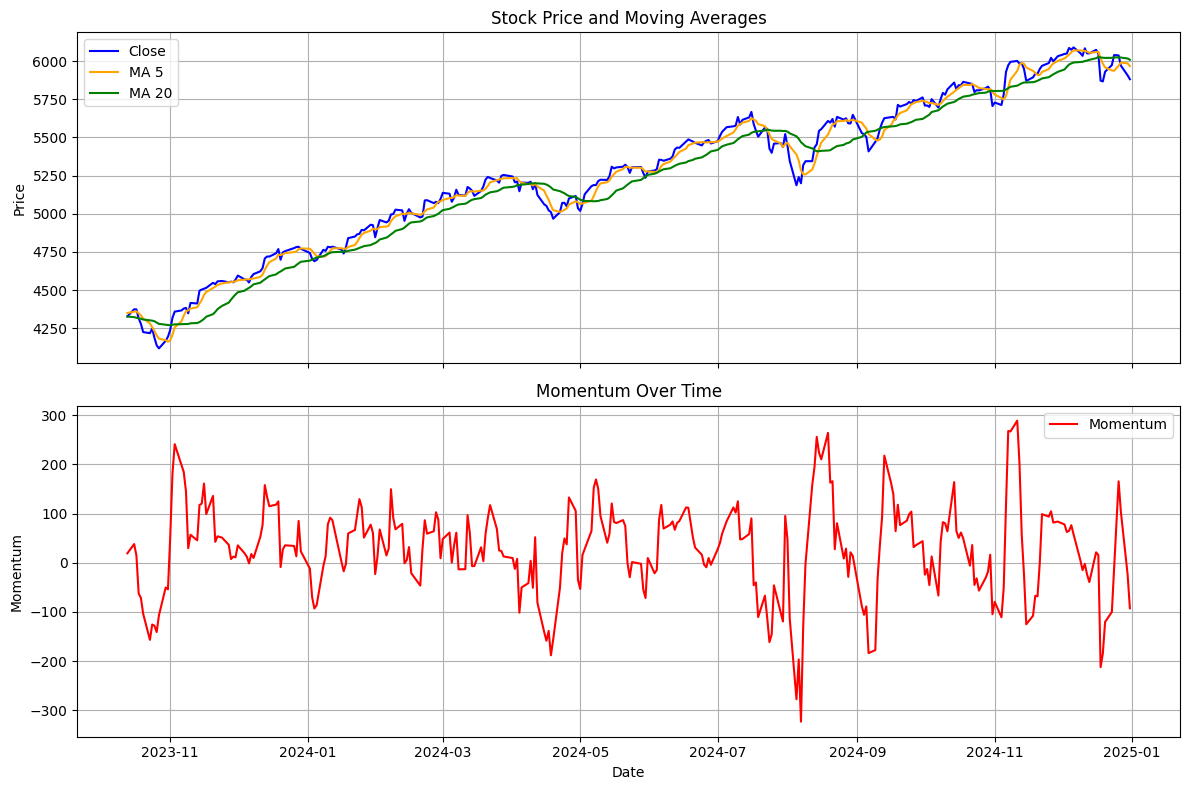

In [205]:
%matplotlib inline

# Create 2 subplots, stacked vertically, shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# --- Top plot: Close and moving averages ---
ax1.plot(df.index, df['close'], label='Close', color='blue')
ax1.plot(df.index, df['ma_5'], label='MA 5', color='orange')
ax1.plot(df.index, df['ma_20'], label='MA 20', color='green')
ax1.set_ylabel('Price')
ax1.set_title('Stock Price and Moving Averages')
ax1.legend()
ax1.grid(True)

# --- Bottom plot: Momentum ---
ax2.plot(df.index, df['momentum'], label='Momentum', color='red')
ax2.set_ylabel('Momentum')
ax2.set_xlabel('Date')
ax2.set_title('Momentum Over Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()  # adjusts spacing so titles/labels don't overlap
plt.show()

### Define prediction target

In [208]:
# We are creating collumn of values that represents what we want the model to predict
# providing historical data to train model with
# Check if tomorrow is higher or lower, assign 0 or 1 for this
# Using shift(-1) is how we align “future information” with today’s features.

df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)

In [209]:
# Inout feature into model
X = df[["return", "ma_5", "ma_20", "momentum"]]

# Target output selected
y = df["target"]

### Train a simple model

Using train test split to work with the historical data

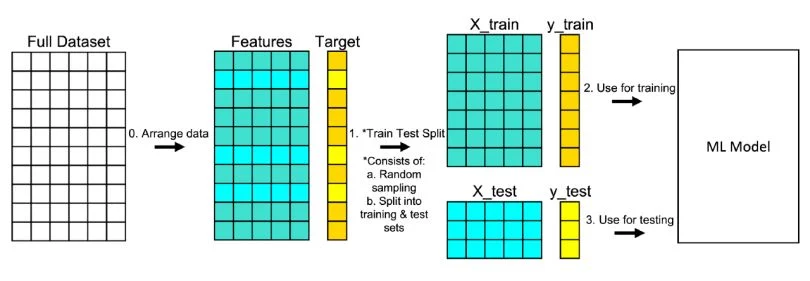

#### Logistic Regression

In [210]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False
)

# Fit the model
model = LogisticRegression()
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [211]:
# Make prediction on the unseen test set
preds = model.predict(X_test) # array of 0 or 1

# Accuracy = number of correct predictions / total predictions
# In this case accuracy = win rate but we are not factoring in the profitability
print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 0.5194805194805194


In [215]:
X_test

,return,ma_5,ma_20,momentum
Date,,,,
2024-09-12,0.007495,5504.975879,5564.070483,92.349609
2024-09-13,0.005408,5548.495898,5568.210474,217.600098
2024-09-16,0.001257,5580.903906,5572.152466,162.040039
2024-09-17,0.000265,5608.715918,5573.468970,139.060059
2024-09-18,-0.002896,5621.541895,5574.525952,64.129883
...,...,...,...,...
2024-12-24,0.011043,5936.840039,6024.241504,-10.569824
2024-12-26,-0.000406,5969.925977,6025.039502,165.429688
2024-12-27,-0.011056,5990.677930,6023.644482,103.759766


In [218]:
# original OHLC data
price_df = data.copy()

# find prices that correspond to X_test
test_prices = price_df.loc[X_test.index]
test_prices = test_prices[["open", "high", "low", "close"]]


In [219]:
test_prices

,open,high,low,close
Date,,,,
2024-09-12,5557.479980,5600.709961,5535.500000,5595.759766
2024-09-13,5603.339844,5636.270020,5601.649902,5626.020020
2024-09-16,5615.209961,5636.049805,5604.529785,5633.089844
2024-09-17,5655.509766,5670.810059,5614.049805,5634.580078
2024-09-18,5641.680176,5689.750000,5615.080078,5618.259766
...,...,...,...,...
2024-12-24,5984.629883,6040.100098,5981.439941,6040.040039
2024-12-26,6024.970215,6049.750000,6007.370117,6037.589844
2024-12-27,6006.169922,6006.169922,5932.950195,5970.839844


Backtesting

In [259]:
# make new df for backtester to use 
backtester_df = test_prices.copy()
backtester_df["prediction"] = preds
# this fixes lookahead bias by shifting predictions forward by 1
backtester_df["prediction"] = backtester_df["prediction"].shift(1)

# backtester_df.columns = [col[0].lower() if col[0] != 'prediction' else 'prediction'
#                    for col in backtester_df.columns]

print(backtester_df)
# df must have datetime index
# backtester_df.index = pd.to_datetime(backtester_df.index)
# backtester_df = backtester_df.reset_index(drop=True)

# backtester_df.set_index('date', inplace=True)

backtester_df.dropna(inplace=True)
backtester_df = backtester_df.replace([float("inf"), float("-inf")], None)
backtester_df['prediction'] = np.where(backtester_df['prediction'] == 1, 1000, 500)
print(backtester_df)

                   open         high          low        close  prediction
Date                                                                      
2024-09-12  5557.479980  5600.709961  5535.500000  5595.759766         NaN
2024-09-13  5603.339844  5636.270020  5601.649902  5626.020020         1.0
2024-09-16  5615.209961  5636.049805  5604.529785  5633.089844         1.0
2024-09-17  5655.509766  5670.810059  5614.049805  5634.580078         1.0
2024-09-18  5641.680176  5689.750000  5615.080078  5618.259766         1.0
...                 ...          ...          ...          ...         ...
2024-12-24  5984.629883  6040.100098  5981.439941  6040.040039         1.0
2024-12-26  6024.970215  6049.750000  6007.370117  6037.589844         1.0
2024-12-27  6006.169922  6006.169922  5932.950195  5970.839844         1.0
2024-12-30  5920.669922  5940.790039  5869.160156  5906.939941         1.0
2024-12-31  5919.740234  5929.740234  5868.859863  5881.629883         1.0

[77 rows x 5 columns]
  

In [248]:
backtester_df

,open,high,low,close,prediction
Date,,,,,
2024-09-13,5603.339844,5636.270020,5601.649902,5626.020020,1000
2024-09-16,5615.209961,5636.049805,5604.529785,5633.089844,1000
2024-09-17,5655.509766,5670.810059,5614.049805,5634.580078,1000
2024-09-18,5641.680176,5689.750000,5615.080078,5618.259766,1000
2024-09-19,5702.629883,5733.569824,5686.419922,5713.640137,1000
...,...,...,...,...,...
2024-12-24,5984.629883,6040.100098,5981.439941,6040.040039,1000
2024-12-26,6024.970215,6049.750000,6007.370117,6037.589844,1000
2024-12-27,6006.169922,6006.169922,5932.950195,5970.839844,1000


In [249]:
print(backtester_df.index)


DatetimeIndex(['2024-09-13', '2024-09-16', '2024-09-17', '2024-09-18',
               '2024-09-19', '2024-09-20', '2024-09-23', '2024-09-24',
               '2024-09-25', '2024-09-26', '2024-09-27', '2024-09-30',
               '2024-10-01', '2024-10-02', '2024-10-03', '2024-10-04',
               '2024-10-07', '2024-10-08', '2024-10-09', '2024-10-10',
               '2024-10-11', '2024-10-14', '2024-10-15', '2024-10-16',
               '2024-10-17', '2024-10-18', '2024-10-21', '2024-10-22',
               '2024-10-23', '2024-10-24', '2024-10-25', '2024-10-28',
               '2024-10-29', '2024-10-30', '2024-10-31', '2024-11-01',
               '2024-11-04', '2024-11-05', '2024-11-06', '2024-11-07',
               '2024-11-08', '2024-11-11', '2024-11-12', '2024-11-13',
               '2024-11-14', '2024-11-15', '2024-11-18', '2024-11-19',
               '2024-11-20', '2024-11-21', '2024-11-22', '2024-11-25',
               '2024-11-26', '2024-11-27', '2024-11-29', '2024-12-02',
      

In [253]:
class PandasMLData(bt.feeds.PandasData):
    lines = ('prediction',) # adds new line for prediction
    params = (('prediction', 'prediction'),) # tells backtrader which column to use (last one)

    # plotlines = dict(
    #     prediction=dict(
    #         marker='^',        # arrow up
    #         markersize=8,
    #         color='green',
    #         fillstyle='full',
    #         subplot=False       # plot on the main price chart
    #     )
    # )

class MLStrategy(bt.Strategy):
    def __init__(self):
        self.pred = self.data.prediction

    # this is a generic class that buys when prediction is 1 and sells when 0
    def next(self):

        if pred == 1 and not self.position:
            self.buy(size=1)

        elif pred == 0 and self.position:
            self.sell(size=1)

        # if self.pred[0] == 1:
        #     # Add a buy marker
        #     self.buy()  # optional if you want to actually backtest
        #     # Plot marker
        #     self.lines.prediction[0] = self.data.close[0]  # marker height
        # else:
        #     self.lines.prediction[0] = float('nan')        # don't show

In [254]:
cerebro = bt.Cerebro() # create backtester instance
cerebro.broker.setcash(10_000)

data_feed = PandasMLData(dataname=backtester_df, timeframe=bt.TimeFrame.Days)

cerebro.adddata(data_feed, name="S&P 500")

cerebro.addstrategy(MLStrategy)

cerebro.run()
cerebro.plot()


<IPython.core.display.Javascript object>

ValueError: Axis limits cannot be NaN or Inf

#### Random Forest

In [24]:
model = RandomForestClassifier(
    n_estimators=100,   # number of trees in the forest
    max_depth=5,        # limit tree depth to avoid overfitting
    random_state=42     # for reproducibility
)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.4483870967741935


<Axes: title={'center': 'Feature Importance'}, xlabel='Price,Ticker'>

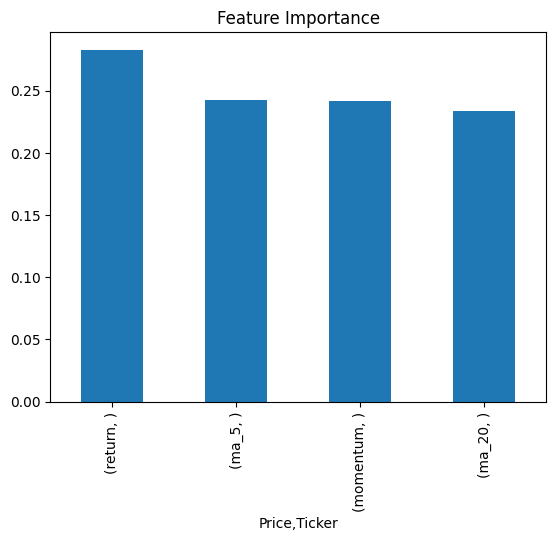

In [25]:
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=False).plot(kind='bar', title='Feature Importance')